In [1388]:
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.special import rel_entr  # KL divergence helper

# ---------- ENVIRONMENT -----------
class IPDEnvironment:
    """
    IPD Environment:
    - States are integers {0=CC, 1=CD, 2=DC, 3=DD}
    - Each step returns the resulting state based on actions of Agent 1 and Agent 2:
        (C=0, D=1) → state transitions: 
            (0,0) → 0 (CC), (0,1) → 1 (CD), 
            (1,0) → 2 (DC), (1,1) → 3 (DD)
    """
    def __init__(self):
        self.state = None
        self.reset()

    def reset(self):
        # Start from a random initial state
        self.state = np.random.choice(4)
        return self.state

    def step(self, a1, a2):
        if   (a1==0 and a2==0): self.state = 0
        elif (a1==0 and a2==1): self.state = 1
        elif (a1==1 and a2==0): self.state = 2
        else:                   self.state = 3
        return self.state

# ✅ Quick test
env = IPDEnvironment()
print("Initial state:", env.state)
print("Next state if Agent1=0, Agent2=1:", env.step(0, 1))


Initial state: 0
Next state if Agent1=0, Agent2=1: 1


In [1389]:
# === Hyperparameter Configuration ===

# Learning rates
default_eta1 = 0.6
default_eta2 = 0.6

# Inverse precisions (α)
default_alpha1 = 6
default_alpha2 = 6
# Epistemic weighting (γ)
default_gamma = 0.0

# Simulation settings
default_N = 500    # number of trials
default_runs = 15     # number of repeated simulations for averaging

# Preferences
C1 = np.array([3, 0.5, 4, 1], dtype=float)
C2 = np.array([3, 4, 0.5, 1], dtype=float)


In [1390]:
class ActiveInferenceAgent:
    """
    Active Inference Agent for IPD:
    - Learns transition model B via Dirichlet counts (pB).
    - Infers hidden states via observation model A.
    - Selects actions by minimizing full Expected Free Energy (EFE).
      where EFE = Risk - gamma * Epistemic Value.
    """
    def __init__(self, name, C, alpha=4.0, eta=0.3, gamma=1.0):
        self.name   = name
        self.alpha  = alpha    # Softmax precision
        self.eta    = eta      # Learning rate
        self.gamma  = gamma    # Epistemic scaling

        # Preferences over states (C): raw rewards given
        self.C = C

        # Build normalized preferred state distribution
        self.Pref = np.exp(self.C)
        self.Pref = self.Pref / (np.sum(self.Pref) + 1e-15)

        # Transition model: pB counts → normalized B matrix
        self.pB = np.ones((4, 4, 2))  # Dirichlet prior counts
        self.B  = np.zeros((4, 4, 2)) # Transition probabilities
        self._normalize_B()

        # Observation model (likelihood): identity matrix
        self.A = np.eye(4)  # Perfect observation: P(o|s)

        # Prior over hidden states: uniform
        self.D = np.ones(4) / 4

        # Current posterior over hidden states
        self.qs = self.D.copy()

    def _normalize_B(self):
        """ Normalize pB to get B transition probabilities. """
        for old_s in range(4):
            for action in range(2):
                col_sum = self.pB[:, old_s, action].sum()
                self.B[:, old_s, action] = self.pB[:, old_s, action] / (col_sum + 1e-15)

    def observe_and_infer_state(self, obs_state):
        """ Bayesian update of hidden states after observing an observation. """
        likelihood = self.A[obs_state, :]  # P(o | s)
        posterior = likelihood * self.D
        self.qs = posterior / (np.sum(posterior) + 1e-15)

    def compute_negEFE_for_action(self, a):
        """
        Compute expected free energy for an action a:
        G(a) = Risk - gamma * EpistemicValue
        """
        eps = 1e-8

        # Predict next states: marginalize over current belief qs
        pred_states = np.zeros(4)
        for s in range(4):
            pred_states += self.qs[s] * self.B[:, s, a]

        # Risk term: KL divergence between predicted states and preferred states
        risk = np.sum(pred_states * (np.log(pred_states + eps) - np.log(self.Pref + eps)))

        # Epistemic value: entropy over predicted observations
        pred_obs = self.A @ pred_states
        entropy = -np.sum(pred_obs * np.log(pred_obs + eps))

        # Full expected free energy
        return risk - self.gamma * entropy



    def select_action(self):
        """ Softmax over negative EFE to select action. """
        Gc = self.compute_negEFE_for_action(0)  # EFE for cooperation
        Gd = self.compute_negEFE_for_action(1)  # EFE for defection

        # Softmax action selection
        Xc = -self.alpha * Gc
        Xd = -self.alpha * Gd
        pC = np.exp(Xc) / (np.exp(Xc) + np.exp(Xd) + 1e-15)

        return 0 if np.random.rand() < pC else 1  # 0 = cooperate, 1 = defect

    def update_transition_model(self, old_state, action, new_state):
        """
        Dirichlet pseudo-count update with decay:
        1) Apply decay to all pseudo-counts for the given (old_state, action) pair.
        2) Increment the pseudo-count for the observed transition.
        3) Normalize to obtain updated transition probabilities.
        """
        # 1) Apply decay to existing pseudo-counts
        self.pB[:, old_state, action] *= (1 - self.eta)

        # 2) Increment the count for the observed transition
        self.pB[new_state, old_state, action] += self.eta

        # 3) Normalize to ensure probabilities sum to 1
        self._normalize_B()


    def compute_efes(self):
        """ Return EFE for both possible actions (cooperate and defect). """
        return self.compute_negEFE_for_action(0), self.compute_negEFE_for_action(1)


In [1391]:
# === MAIN SIMULATION LOOP ===
# Place this cell immediately after:
#   • IPDEnvironment class
#   • ActiveInferenceAgent class
#   • Helper functions (run_simulation, average_cooperation)
# and before any parameter‐sweep / heatmap cells.

np.random.seed(42)

C1 = np.array([3, 0.5, 4, 1], dtype=float)
C2 = np.array([3, 4, 0.5, 1], dtype=float)

# Instantiate environment and two agents (same rewards, different names)
env       = IPDEnvironment()
agent1    = ActiveInferenceAgent("A1", C1, alpha=default_alpha1, eta=default_eta1, gamma=default_gamma)
agent2    = ActiveInferenceAgent("A2", C2, alpha=default_alpha2, eta=default_eta2, gamma=default_gamma)

# Initialize state
old_state = env.state

# Number of rounds
N = default_N

# ——— LOGGING CONTAINERS ———
states_history     = []
a1_history         = []
a2_history         = []

# Expected free energies
efe1_C = []
efe1_D = []
efe2_C = []
efe2_D = []

# Snapshots of B matrices (for later visualization)
B_snap_1 = []
B_snap_2 = []

# ——— SIMULATION ———
for t in range(N):
    # 1) State inference
    agent1.observe_and_infer_state(env.state)
    agent2.observe_and_infer_state(env.state)

    # 2) Compute and log EFEs
    Gc1, Gd1 = agent1.compute_efes()
    efe1_C.append(Gc1); efe1_D.append(Gd1)
    Gc2, Gd2 = agent2.compute_efes()
    efe2_C.append(Gc2); efe2_D.append(Gd2)

    # 3) Action selection (random on t=0)
    if t == 0:
        a1 = np.random.choice([0, 1])
        a2 = np.random.choice([0, 1])
    else:
        a1 = agent1.select_action()
        a2 = agent2.select_action()

    # 4) Environment transition
    s_new = env.step(a1, a2)

    # 5) Learning (update B)
    agent1.update_transition_model(old_state, a1, s_new)
    agent2.update_transition_model(old_state, a2, s_new)

    # 6) Snapshot B for later plotting
    B_snap_1.append(agent1.B.copy())
    B_snap_2.append(agent2.B.copy())

    # 7) Log actions & states
    states_history.append(s_new)
    a1_history.append(a1)
    a2_history.append(a2)

    # Prepare for next iteration
    old_state = s_new

print("Simulation complete. Final state:", states_history[-1])


Simulation complete. Final state: 0


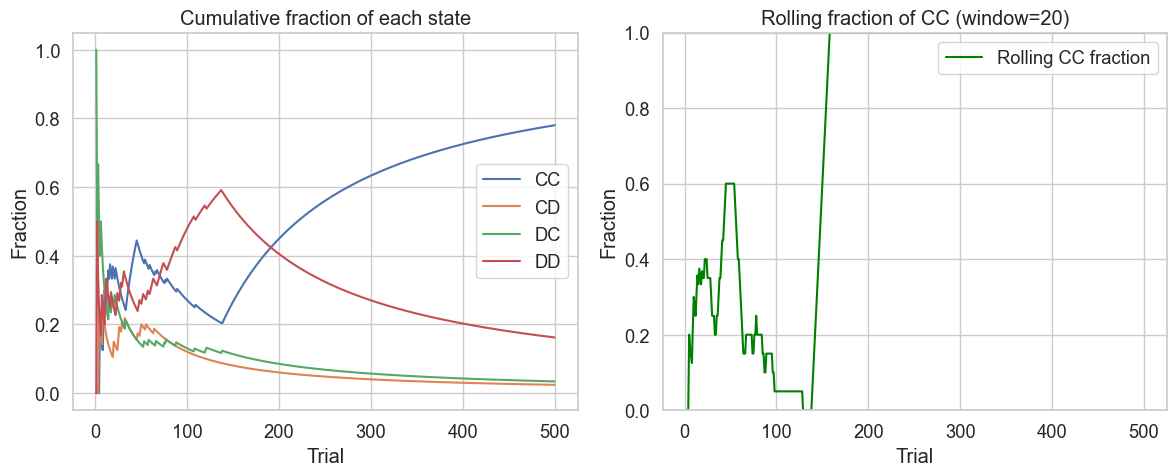


=== Final fraction of states over entire run ===
CC: 78.00%
CD: 2.40%
DC: 3.40%
DD: 16.20%


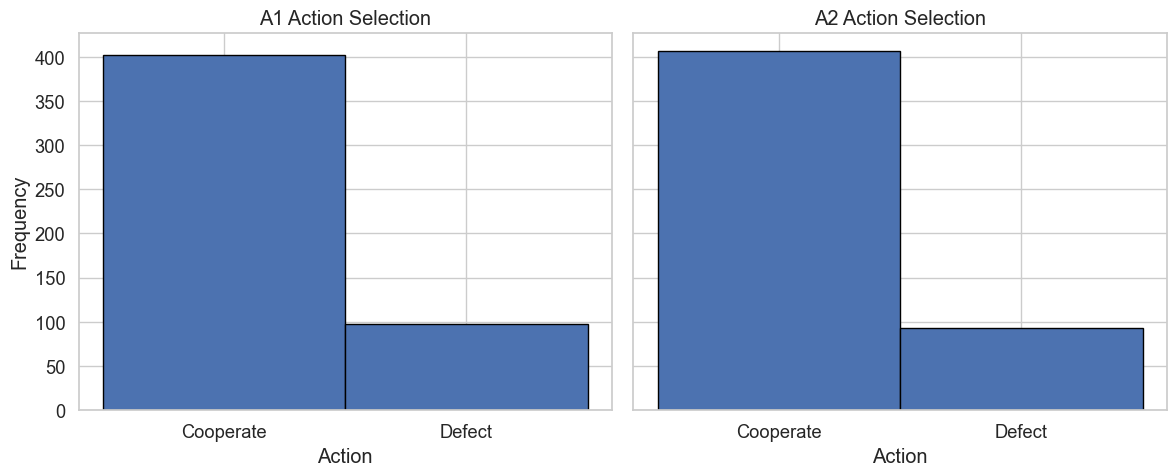

In [1392]:
import numpy as np
import matplotlib.pyplot as plt

# --- Plotting: State Frequencies and Cooperation Dynamics ---
states_history = np.array(states_history)

# (1) Cumulative frequency of each state over time
state_counts = np.zeros((4, N), dtype=float)
for t in range(N):
    s = states_history[t]
    state_counts[s, t] = 1.0
cum_counts = np.cumsum(state_counts, axis=1)

# (2) Rolling fraction of 'CC' (cooperation-cooperation)
window_size = 20
rolling_frac_cc = np.zeros(N)
for t in range(N):
    left = max(0, t - window_size + 1)
    segment = states_history[left:t + 1]
    cc_count = np.sum(segment == 0)
    rolling_frac_cc[t] = cc_count / len(segment)

# --- Subplots: cumulative + rolling plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
t_range = np.arange(1, N + 1)

# Plot 1: Cumulative fraction of each state
for i, lbl in enumerate(["CC", "CD", "DC", "DD"]):
    frac_i = cum_counts[i, :] / t_range
    axes[0].plot(t_range, frac_i, label=lbl)
axes[0].set_title("Cumulative fraction of each state")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Fraction")
axes[0].legend()

# Plot 2: Rolling fraction of CC (window=20)
axes[1].plot(t_range, rolling_frac_cc, color='green', label="Rolling CC fraction")
axes[1].set_title("Rolling fraction of CC (window=20)")
axes[1].set_xlabel("Trial")
axes[1].set_ylabel("Fraction")
axes[1].set_ylim([0, 1])
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Final State Summary ---
final_counts = cum_counts[:, -1]
final_fracs = final_counts / N
print("\n=== Final fraction of states over entire run ===")
for i, lbl in enumerate(["CC", "CD", "DC", "DD"]):
    print(f"{lbl}: {final_fracs[i]*100:.2f}%")

# --- Action Histograms for Both Agents ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
action_labels = ['Cooperate', 'Defect']
bins = np.arange(len(action_labels) + 1) - 0.5  # center bins on actions

# Agent 1
axes[0].hist(a1_history, bins=bins, edgecolor='black')
axes[0].set_xticks(range(len(action_labels)))
axes[0].set_xticklabels(action_labels)
axes[0].set_title(f'{agent1.name} Action Selection')
axes[0].set_xlabel('Action')
axes[0].set_ylabel('Frequency')

# Agent 2
axes[1].hist(a2_history, bins=bins, edgecolor='black')
axes[1].set_xticks(range(len(action_labels)))
axes[1].set_xticklabels(action_labels)
axes[1].set_title(f'{agent2.name} Action Selection')
axes[1].set_xlabel('Action')

plt.tight_layout()
plt.show()


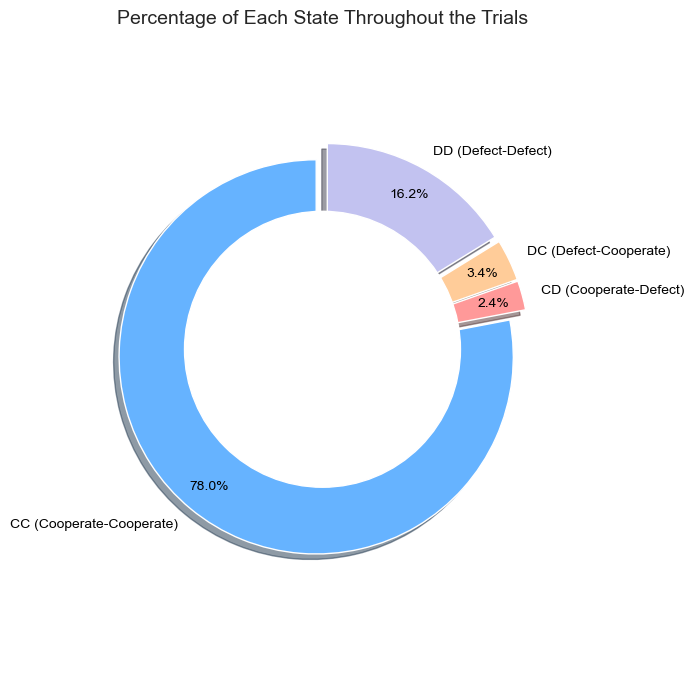

In [1393]:
# --- Pie Chart of Final State Distribution ---
fig, ax = plt.subplots(figsize=(7, 7))

# Count how many times each state occurred
state_counts = np.bincount(states_history, minlength=4)

# Define state labels and visual style
state_labels = ['CC (Cooperate-Cooperate)', 'CD (Cooperate-Defect)', 
                'DC (Defect-Cooperate)', 'DD (Defect-Defect)']
colors = ['#66b3ff', '#ff9999', '#ffcc99', '#c2c2f0']
explode = [0.05] * 4  # Separate slices slightly

# Plot pie chart
wedges, texts, autotexts = ax.pie(
    state_counts,
    labels=state_labels,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    colors=colors,
    pctdistance=0.85,
    shadow=True,
    textprops=dict(color='black', fontsize=10)
)

# Add inner circle to make donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

ax.axis('equal')  # Equal aspect ratio for symmetry
ax.set_title('Percentage of Each State Throughout the Trials', fontsize=14)

plt.tight_layout()
plt.show()


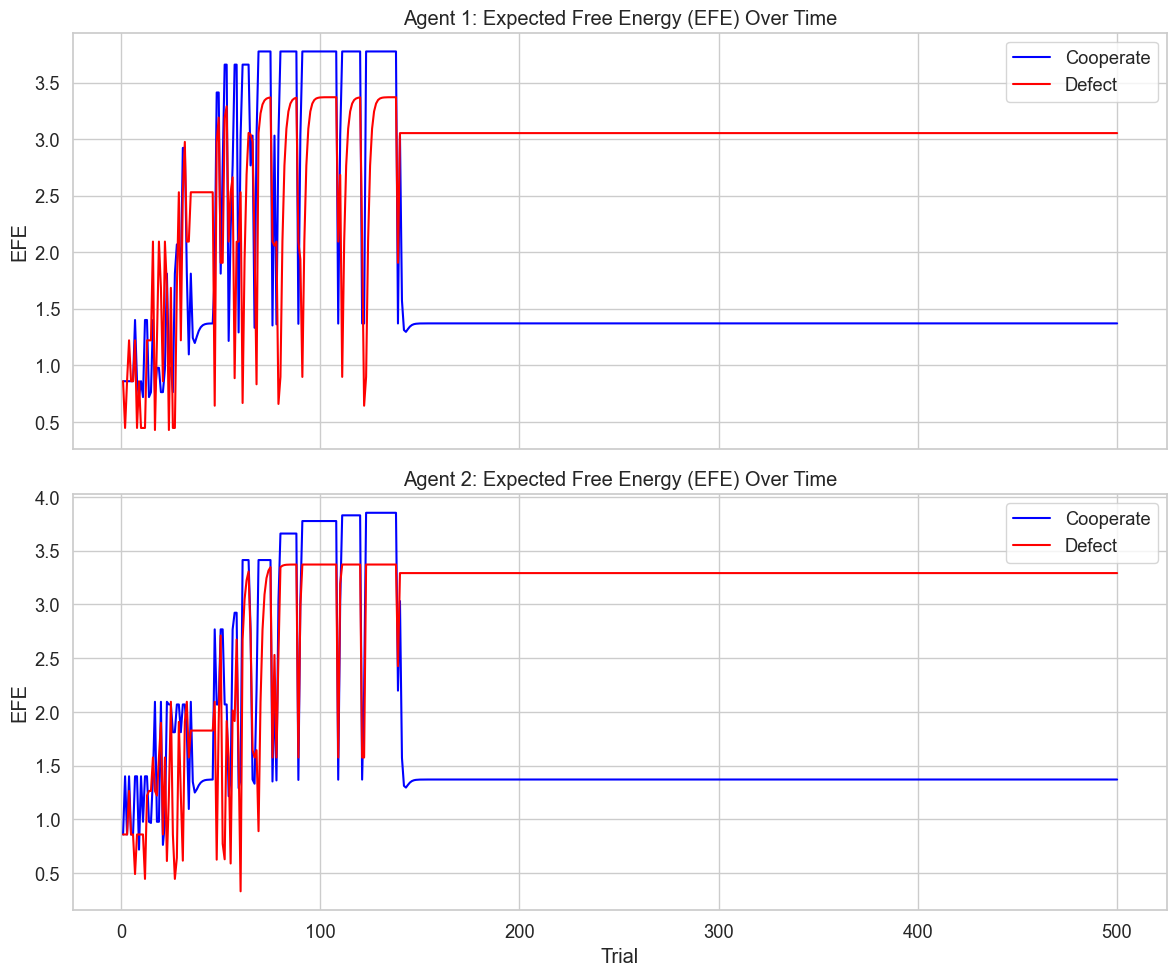

In [1394]:
# --- Plot: EFE for Both Agents Over Time ---
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

t_range = np.arange(1, N + 1)

# Agent 1
axes[0].plot(t_range, efe1_C, label='Cooperate', color='blue')
axes[0].plot(t_range, efe1_D, label='Defect', color='red')
axes[0].set_title('Agent 1: Expected Free Energy (EFE) Over Time')
axes[0].set_ylabel('EFE')
axes[0].legend()

# Agent 2
axes[1].plot(t_range, efe2_C, label='Cooperate', color='blue')
axes[1].plot(t_range, efe2_D, label='Defect', color='red')
axes[1].set_title('Agent 2: Expected Free Energy (EFE) Over Time')
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('EFE')
axes[1].legend()

plt.tight_layout()
plt.show()


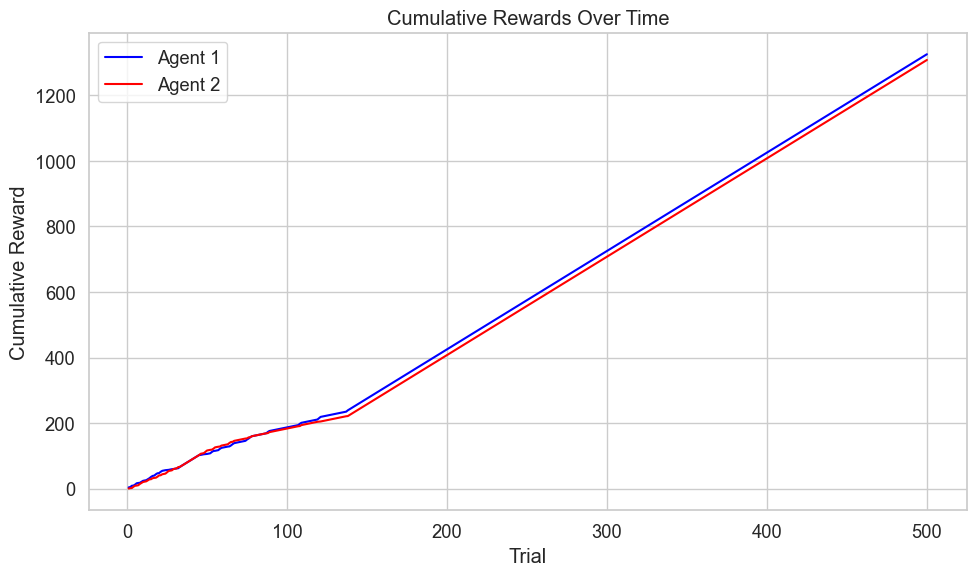

In [1395]:
# --- Cumulative Rewards Over Time ---
fig, ax = plt.subplots(figsize=(10, 6))

# Calculate reward totals at each step
cumulative_rewards_agent1 = np.cumsum([C1[state] for state in states_history])
cumulative_rewards_agent2 = np.cumsum([C2[state] for state in states_history])

# Plot over trials
ax.plot(t_range, cumulative_rewards_agent1, label='Agent 1', color='blue')
ax.plot(t_range, cumulative_rewards_agent2, label='Agent 2', color='red')

ax.set_title('Cumulative Rewards Over Time')
ax.set_xlabel('Trial')
ax.set_ylabel('Cumulative Reward')
ax.legend()

plt.tight_layout()
plt.show()


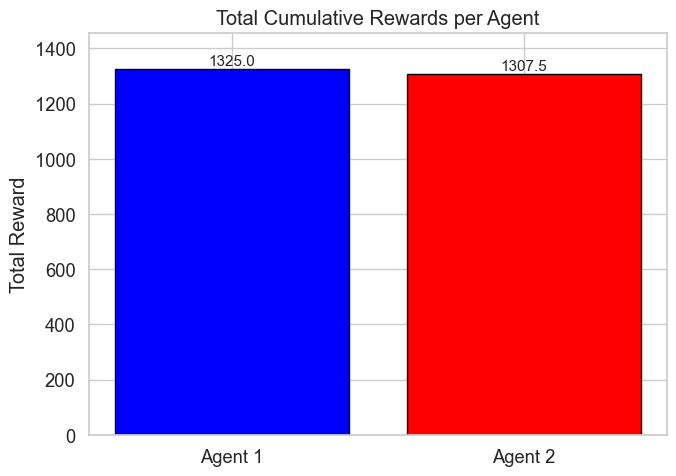

In [1396]:
# --- Final Reward Comparison ---
final_rewards_2agents = [
    np.sum([C1[s] for s in states_history]),
    np.sum([C2[s] for s in states_history])
]

fig, ax = plt.subplots(figsize=(7, 5))
agent_labels = ['Agent 1', 'Agent 2']
colors_2 = ['blue', 'red']

bars = ax.bar(agent_labels, final_rewards_2agents, color=colors_2, edgecolor='black')

# Annotate each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 2, f'{height:.1f}', ha='center', va='bottom', fontsize=11)

ax.set_title('Total Cumulative Rewards per Agent')
ax.set_ylabel('Total Reward')
ax.set_ylim(0, max(final_rewards_2agents) * 1.1)

plt.tight_layout()
plt.show()


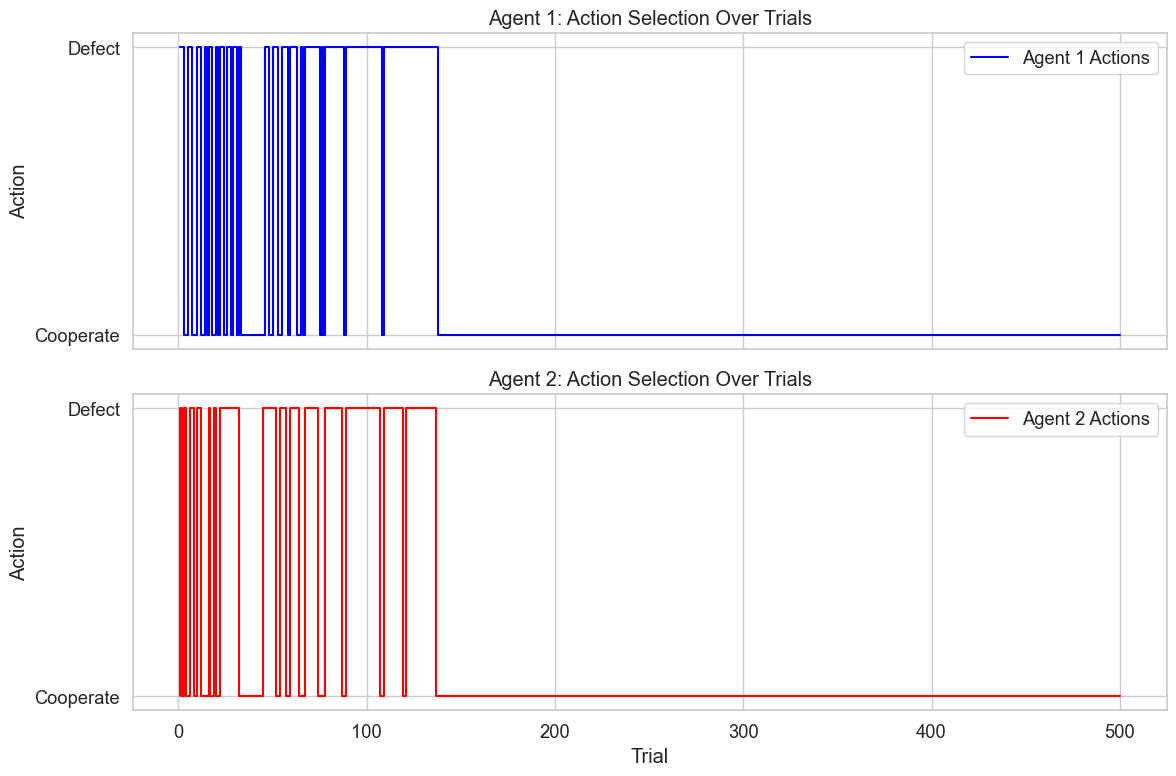

In [1397]:
# --- Additional Plot: Agents' Action Selections Over Time ---
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Trial indices
t_range = np.arange(1, N + 1)

# Plot Agent 1's actions
axes[0].plot(t_range, a1_history, drawstyle='steps-pre', label='Agent 1 Actions', color='blue')
axes[0].set_title('Agent 1: Action Selection Over Trials')
axes[0].set_ylabel('Action')
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['Cooperate', 'Defect'])
axes[0].legend()

# Plot Agent 2's actions
axes[1].plot(t_range, a2_history, drawstyle='steps-pre', label='Agent 2 Actions', color='red')
axes[1].set_title('Agent 2: Action Selection Over Trials')
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('Action')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Cooperate', 'Defect'])
axes[1].legend()

plt.tight_layout()
plt.show()


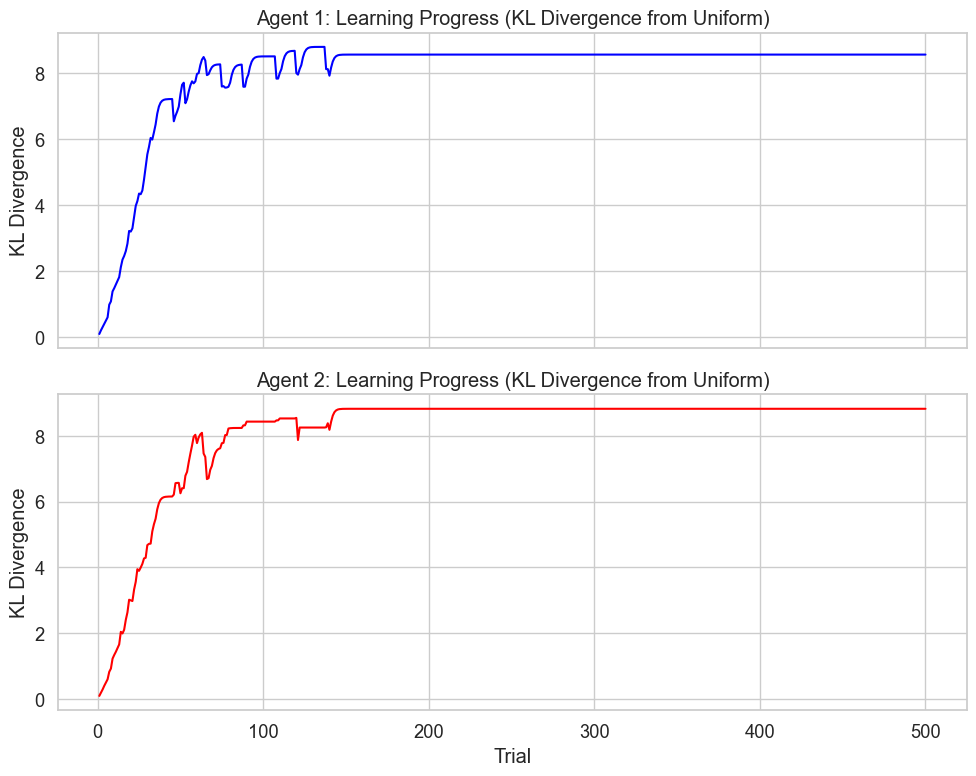

In [1398]:
# --- Learning Progress via KL Divergence from Uniform ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
kl_colors = ['blue', 'red']

for i, B_snapshots in enumerate([B_snap_1, B_snap_2]):
    kl_history = []
    for B in B_snapshots:
        kl = 0
        for old_s in range(4):
            for a in range(2):
                current_dist = B[:, old_s, a]
                prior_dist = np.ones(4) / 4  # uniform prior over next states
                kl += np.sum(rel_entr(current_dist, prior_dist))
        kl_history.append(kl)

    axes[i].plot(range(1, len(kl_history) + 1), kl_history, color=kl_colors[i])
    axes[i].set_title(f'Agent {i+1}: Learning Progress (KL Divergence from Uniform)')
    axes[i].set_ylabel('KL Divergence')
    axes[i].grid(True)

axes[-1].set_xlabel('Trial')
plt.tight_layout()
plt.show()


In [1399]:
import numpy as np

def run_simulation(eta1, eta2, gamma, N):
    C1 = np.array([3, 0.5, 4, 1], dtype=float)
    C2 = np.array([3, 4, 0.5, 1], dtype=float)

    env = IPDEnvironment()
    agent1 = ActiveInferenceAgent("A1", C1, alpha=default_alpha1, eta=eta1, gamma=gamma)
    agent2 = ActiveInferenceAgent("A2", C2, alpha=default_alpha2, eta=eta2, gamma=gamma)

    states_history = []
    old_state = env.state

    for t in range(N):
        agent1.observe_and_infer_state(env.state)
        agent2.observe_and_infer_state(env.state)

        if t == 0:
            a1 = np.random.choice([0,1])
            a2 = np.random.choice([0,1])
        else:
            a1 = agent1.select_action()
            a2 = agent2.select_action()

        s_new = env.step(a1, a2)
        agent1.update_transition_model(old_state, a1, s_new)
        agent2.update_transition_model(old_state, a2, s_new)

        states_history.append(s_new)
        old_state = s_new

    # cooperation fraction = fraction of mutual‐cooperate states (state 0)
    return np.mean(np.array(states_history) == 0)


def average_cooperation(eta1, eta2, gamma, runs, N):
    rates = [run_simulation(eta1,eta2,gamma,N) for _ in range(runs)]
    return np.mean(rates)


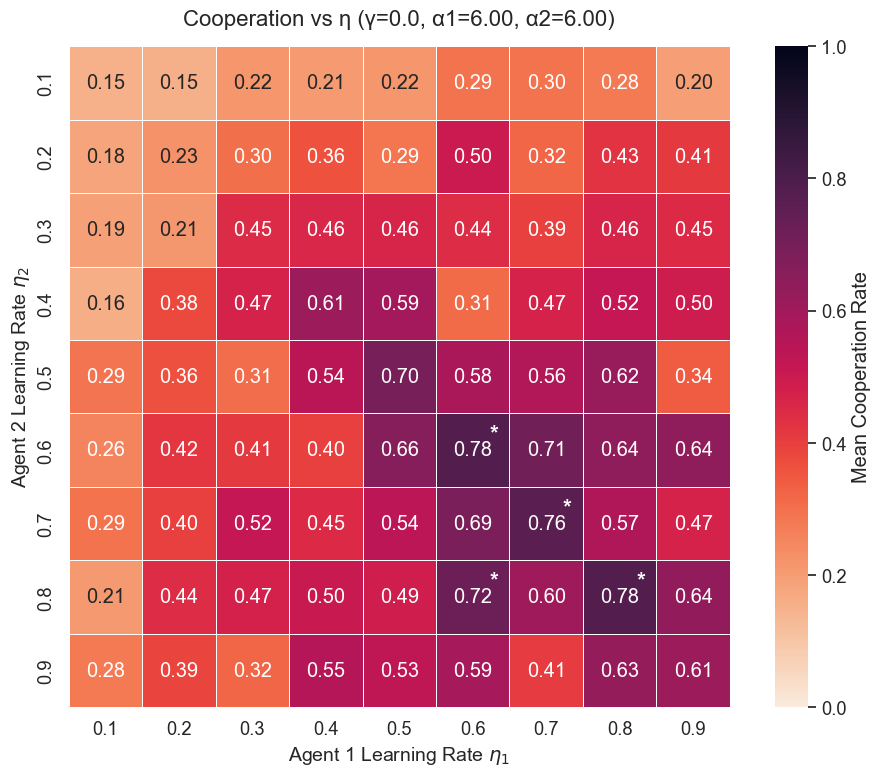

In [1400]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_1samp

# ─── Simulation parameters ────────────────────────────────────────────
np.random.seed(42)
etas = np.round(np.arange(0.1, 1.0, 0.1), 2)
gamma_value = default_gamma
alpha1 = default_alpha1
alpha2 = default_alpha2
R = default_runs      # runs per cell
N = default_N    # trials per run
coop_threshold = 0.60

# ─── Run experiments ─────────────────────────────────────────────────
means = np.zeros((len(etas), len(etas)))
pvals = np.ones_like(means)

for i, eta1 in enumerate(etas):
    for j, eta2 in enumerate(etas):
        coop_rates = np.array([
            run_simulation(eta1, eta2, gamma_value, N)
            for _ in range(R)
        ])
        means[j, i] = coop_rates.mean()
        t_stat, p_two = ttest_1samp(coop_rates, coop_threshold, nan_policy='omit')
        p_one = (p_two/2) if t_stat > 0 else (1 - p_two/2)
        pvals[j, i] = p_one

# ─── Plot: square-style heatmap with significance stars ──────────────────────
sns.set_theme(context="notebook", style="whitegrid", font_scale=1.2)

fig, ax = plt.subplots(figsize=(10, 8))

# Draw heatmap using square cells
sns.heatmap(
    means,
    xticklabels=np.round(etas, 2),
    yticklabels=np.round(etas, 2),
    cmap="rocket_r",
    vmin=0, vmax=1,
    annot=True, fmt=".2f",
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={"label": "Mean Cooperation Rate"},
    ax=ax
)

# Overlay significance stars
for i, eta1 in enumerate(etas):
    for j, eta2 in enumerate(etas):
        if pvals[j, i] < 0.05:
            ax.text(
                i + 0.85, j + 0.15, " *",
                ha="right", va="top",
                color="white", fontsize=16, weight="bold"
            )

# Axis labels and title
ax.set_xlabel("Agent 1 Learning Rate $\\eta_1$", fontsize=14)
ax.set_ylabel("Agent 2 Learning Rate $\\eta_2$", fontsize=14)
ax.set_title(f"Cooperation vs η (γ={gamma_value}, α1={alpha1:.2f}, α2={alpha2:.2f})", fontsize=16, pad=15)

plt.tight_layout()
plt.show()


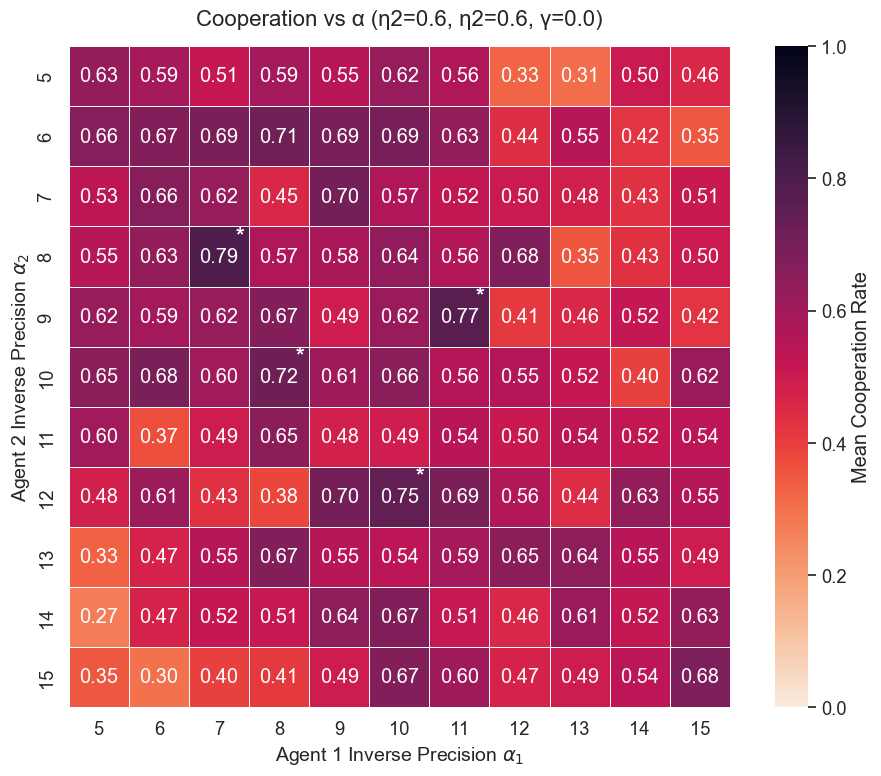

In [1401]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp
import seaborn as sns

# — PARAMETERS —
np.random.seed(42)
gamma_value = default_gamma
eta1 = default_eta1
eta2 = default_eta2
N = default_N        
R = default_runs     
coop_threshold = 0.60

# α grid (inverse precision)
alpha_values = np.round(np.arange(5, 16, 1), 2)

# storage
means = np.zeros((len(alpha_values), len(alpha_values)))
pvals = np.ones_like(means)

# the wrapped simulation from before
def run_simulation_alpha(alpha1, alpha2, eta1, eta2, gamma, N):
    C1 = np.array([3, 0.5, 4, 1], dtype=float)
    C2 = np.array([3, 4, 0.5, 1], dtype=float)
    env = IPDEnvironment()
    agent1 = ActiveInferenceAgent("A1", C1, alpha=alpha1, eta=eta1, gamma=gamma)
    agent2 = ActiveInferenceAgent("A2", C2, alpha=alpha2, eta=eta2, gamma=gamma)
    states = []
    old1 = env.state; old2 = env.state
    for t in range(N):
        agent1.observe_and_infer_state(env.state)
        agent2.observe_and_infer_state(env.state)
        if t == 0:
            a1, a2 = np.random.choice([0,1]), np.random.choice([0,1])
        else:
            a1 = agent1.select_action()
            a2 = agent2.select_action()
        s = env.step(a1, a2)
        agent1.update_transition_model(old1, a1, s)
        agent2.update_transition_model(old2, a2, s)
        states.append(s)
        old1 = old2 = s
    # return fraction of CC (state==0)
    return np.mean(np.array(states) == 0)

# sweep
for i, a1 in enumerate(alpha_values):
    for j, a2 in enumerate(alpha_values):
        samples = np.array([
            run_simulation_alpha(a1, a2, eta1, eta2, gamma_value, N)
            for _ in range(R)
        ])
        means[j, i] = samples.mean()
        # one-sided t-test H0: mean <= threshold vs H1: mean > threshold
        t, p2 = ttest_1samp(samples, coop_threshold, nan_policy='omit')
        p_one = (p2/2) if t > 0 else (1 - p2/2)
        pvals[j, i] = p_one

# ─── Plot: square heatmap with cooperation values and significance stars ─────
sns.set_theme(context="notebook", style="whitegrid", font_scale=1.2)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    means,
    xticklabels=np.round(alpha_values, 2),
    yticklabels=np.round(alpha_values, 2),
    cmap="rocket_r",
    vmin=0, vmax=1,
    annot=True, fmt=".2f",
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={"label": "Mean Cooperation Rate"},
    ax=ax
)

# Add significance stars
for i, a1 in enumerate(alpha_values):
    for j, a2 in enumerate(alpha_values):
        if pvals[j, i] < 0.05:
            ax.text(
                i + 0.85, j + 0.15, "*",
                ha="center", va="center",
                color="white", fontsize=16, weight="bold"
            )

# Axis labels and title
ax.set_xlabel("Agent 1 Inverse Precision $\\alpha_1$", fontsize=14)
ax.set_ylabel("Agent 2 Inverse Precision $\\alpha_2$", fontsize=14)
ax.set_title(
    f"Cooperation vs α (η2={eta1}, η2={eta2}, γ={gamma_value})",
    fontsize=16, pad=15
)

plt.tight_layout()
plt.show()


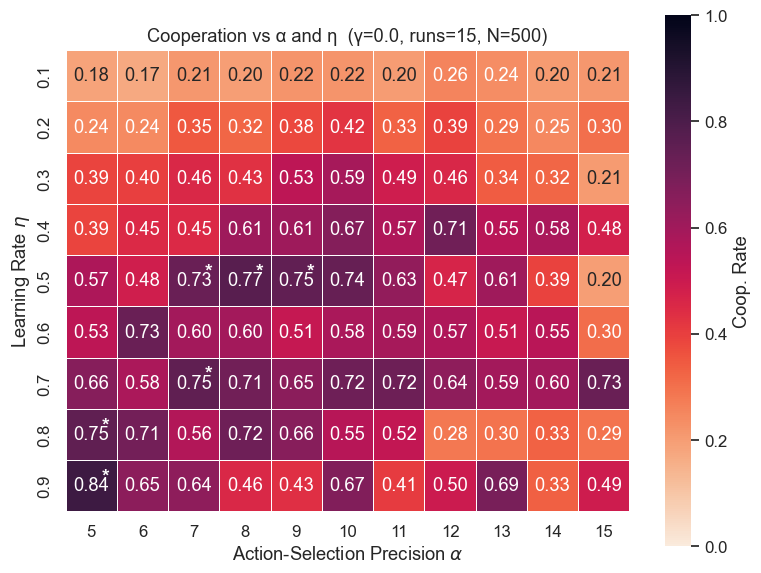

In [1402]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_1samp

# ─── 1) Parameter ranges ───────────────────────────────
alpha_vals = np.round(np.arange(5, 16, 1), 2)   # e.g., 5 to 15
eta_vals = np.round(np.arange(0.1, 0.91, 0.1), 2)
R = default_runs
N = default_N
γ = default_gamma
coop_threshold = 0.60

# ─── 2) Run simulation sweep ────────────────────────────
coop_grid = np.zeros((len(eta_vals), len(alpha_vals)))
pvals = np.ones_like(coop_grid)

for i, η in enumerate(eta_vals):
    for j, α in enumerate(alpha_vals):
        rates = np.array([run_simulation_alpha(α, α, η, η, γ, N) for _ in range(R)])
        coop_grid[i, j] = np.mean(rates)
        t_stat, p_two = ttest_1samp(rates, coop_threshold, nan_policy='omit')
        p_one = (p_two / 2) if t_stat > 0 else (1 - p_two / 2)
        pvals[i, j] = p_one

# ─── 3) Plot heatmap with stars ─────────────────────────
sns.set_theme(context="notebook", style="darkgrid", font_scale=1.1)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    coop_grid,
    xticklabels=alpha_vals,
    yticklabels=eta_vals,
    cmap="rocket_r",
    vmin=0, vmax=1,
    annot=True, fmt=".2f",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={"label": "Coop. Rate"},
    square=True,
    ax=ax
)

# Add significance stars (top-right corner of each square)
for i, η in enumerate(eta_vals):
    for j, α in enumerate(alpha_vals):
        if pvals[i, j] < 0.05:
            ax.text(
                j + 0.85, i + 0.15, "*",
                ha="right", va="top",
                color="white", fontsize=14, weight="bold"
            )

ax.set_xlabel(r"Action-Selection Precision $\alpha$")
ax.set_ylabel(r"Learning Rate $\eta$")
ax.set_title(f"Cooperation vs α and η  (γ={γ}, runs={R}, N={N})")
plt.tight_layout()
plt.show()


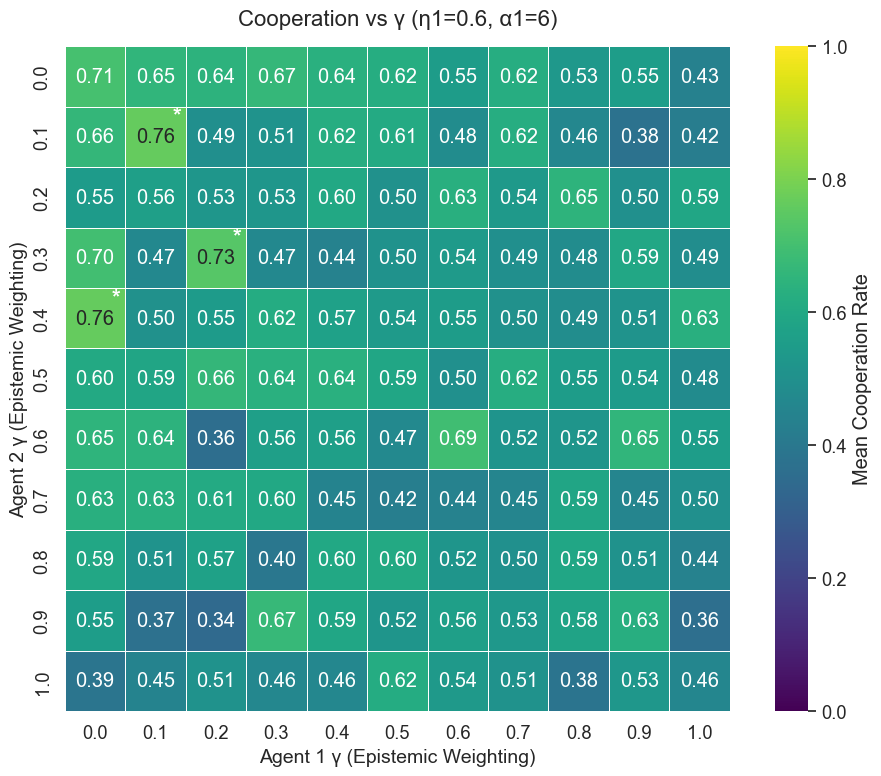

In [1403]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp

# — PARAMETERS —
np.random.seed(42)
eta1 = default_eta1
eta2 = default_eta2
alpha1 = default_alpha1
alpha2 = default_alpha2
N = default_N
R = default_runs
coop_thr = 0.60

# γ grid
gamma_vals = np.round(np.arange(0.0, 1.05, 0.1), 2)

# storage
means = np.zeros((len(gamma_vals), len(gamma_vals)))
pvals = np.ones_like(means)

# wrapped sim function
def run_simulation_gamma(g1, g2, e1, e2, a1, a2, gamma1, gamma2, N):
    C1 = np.array([3, 0.5, 4, 1], float)
    C2 = np.array([3, 4, 0.5, 1], float)
    env = IPDEnvironment()
    A1 = ActiveInferenceAgent("A1", C1, alpha=a1, eta=e1, gamma=g1)
    A2 = ActiveInferenceAgent("A2", C2, alpha=a2, eta=e2, gamma=g2)
    states = []
    old1 = old2 = env.state
    for t in range(N):
        A1.observe_and_infer_state(env.state)
        A2.observe_and_infer_state(env.state)
        if t==0:
            a_1, a_2 = np.random.choice([0,1]), np.random.choice([0,1])
        else:
            a_1, a_2 = A1.select_action(), A2.select_action()
        s = env.step(a_1, a_2)
        A1.update_transition_model(old1, a_1, s)
        A2.update_transition_model(old2, a_2, s)
        states.append(s); old1=old2=s
    return np.mean(np.array(states)==0)

# sweep
for i, g1 in enumerate(gamma_vals):
    for j, g2 in enumerate(gamma_vals):
        samples = [run_simulation_gamma(g1, g2, eta1, eta2, alpha1, alpha2, g1, g2, N)
                   for _ in range(R)]
        samples = np.array(samples)
        means[j,i] = samples.mean()
        t, p2 = ttest_1samp(samples, coop_thr, nan_policy='omit')
        p_one = (p2/2) if t>0 else (1 - p2/2)
        pvals[j,i] = p_one

 # ─── Plot: square heatmap with cooperation values and significance stars ─────
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid", font_scale=1.2)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    means,
    xticklabels=np.round(gamma_vals, 2),
    yticklabels=np.round(gamma_vals, 2),
    cmap="viridis",
    vmin=0, vmax=1,
    annot=True, fmt=".2f",
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={"label": "Mean Cooperation Rate"},
    ax=ax
)

# Add significance stars
for i, g1 in enumerate(gamma_vals):
    for j, g2 in enumerate(gamma_vals):
        if pvals[j, i] < 0.05:
            ax.text(
                i + 0.85, j + 0.15, "*",
                ha="center", va="center",
                color="white", fontsize=16, weight="bold"
            )

# Axis labels and title
ax.set_xlabel("Agent 1 γ (Epistemic Weighting)", fontsize=14)
ax.set_ylabel("Agent 2 γ (Epistemic Weighting)", fontsize=14)
ax.set_title(f"Cooperation vs γ (η1={eta1}, α1={alpha1})", fontsize=16, pad=15)

plt.tight_layout()
plt.show()


In [1404]:
# ─── Cell 1: Define helpers (uses default_N internally) ────────────────────────

import numpy as np
from scipy.stats import sem, ttest_1samp

def run_simulation_with_history(eta1, eta2, gamma):
    """
    Runs a single IPD simulation of length default_N, returning the two agents' action histories.
    Uses default_alpha1, default_alpha2, default_gamma from the notebook globals.
    """
    C1 = np.array([3, 0.5, 4, 1], dtype=float)
    C2 = np.array([3, 4, 0.5, 1], dtype=float)

    env = IPDEnvironment()
    agent1 = ActiveInferenceAgent("A1", C1,
                                  alpha=default_alpha1,
                                  eta=eta1,
                                  gamma=gamma)
    agent2 = ActiveInferenceAgent("A2", C2,
                                  alpha=default_alpha2,
                                  eta=eta2,
                                  gamma=gamma)

    a1_hist, a2_hist = [], []
    # initial random moves
    a1, a2 = np.random.choice([0, 1]), np.random.choice([0, 1])
    a1_hist.append(a1)
    a2_hist.append(a2)
    s_old = env.state

    # run exactly default_N rounds
    for t in range(1, default_N):
        agent1.observe_and_infer_state(s_old)
        agent2.observe_and_infer_state(s_old)
        a1 = agent1.select_action()
        a2 = agent2.select_action()
        s_new = env.step(a1, a2)
        agent1.update_transition_model(s_old, a1, s_new)
        agent2.update_transition_model(s_old, a2, s_new)
        a1_hist.append(a1)
        a2_hist.append(a2)
        s_old = s_new

    return np.array(a1_hist), np.array(a2_hist)


def compute_tft_wsls(a1, a2):
    """
    Computes the four strategy metrics for a single run:
      - P(C_t | C_{t-1})
      - P(D_t | D_{t-1})
      - Win–Stay
      - Lose–Shift
    """
    payoff = {(0, 0): 3, (0, 1): 1, (1, 0): 4, (1, 1): 2}
    cc = dd = cc_tot = dd_tot = 0
    win_stay = win_tot = lose_shift = lose_tot = 0

    for t in range(1, len(a1)):
        prev = (a1[t - 1], a2[t - 1])
        curr = a1[t]
        # TFT counts
        if prev[1] == 0:      # partner cooperated last round
            cc_tot += 1
            if curr == 0:
                cc += 1
        else:                 # partner defected last round
            dd_tot += 1
            if curr == 1:
                dd += 1
        # WSLS counts
        p1 = payoff[prev]
        p2 = payoff[(prev[1], prev[0])]  # the agent's payoff if roles reversed
        if p1 >= p2:         # last round was a "win"
            win_tot += 1
            if curr == a1[t - 1]:
                win_stay += 1
        else:                # last round was a "loss"
            lose_tot += 1
            if curr != a1[t - 1]:
                lose_shift += 1

    return {
        "P(C|C)"   : cc / cc_tot     if cc_tot     else np.nan,
        "P(D|D)"   : dd / dd_tot     if dd_tot     else np.nan,
        "Win–Stay" : win_stay / win_tot   if win_tot   else np.nan,
        "Lose–Shift": lose_shift / lose_tot if lose_tot else np.nan
    }


In [ ]:
# ─── Cell 2: Strategy stats over three η anchors, in a table ─────────────────

import numpy as np
import pandas as pd
from scipy.stats import sem, ttest_1samp

# Simulation settings
np.random.seed(42)
R = 30
etas = [0.1, 0.4, 0.6, 0.8]

# 1) Run sims and compute means, sem, t‐stat, p‐val for each strategy × η
records = []
for eta in etas:
    stats = {k: [] for k in ["P(C|C)", "P(D|D)", "Win–Stay", "Lose–Shift"]}
    for _ in range(R):
        a1, a2 = run_simulation_with_history(eta, eta, default_gamma)
        out = compute_tft_wsls(a1, a2)
        for strat, val in out.items():
            stats[strat].append(val)
    # summarize
    for strat, vals in stats.items():
        arr = np.array(vals)
        t_stat, p_val = ttest_1samp(arr, 0.5, nan_policy="omit")
        records.append({
            "eta":          eta,
            "strategy":     strat,
            "mean":         np.nanmean(arr),
            "sem":          sem(arr, nan_policy="omit"),
            "t_stat":       t_stat,
            "p_val":        p_val
        })

# 2) Build DataFrame and pivot so each stat is its own column
df = pd.DataFrame.from_records(records)
table = df.pivot(index="eta", columns="strategy")[["mean", "sem", "t_stat", "p_val"]]

# 3) Optional: flatten the MultiIndex columns
table.columns = [f"{stat}_{strat}" for stat, strat in table.columns]

# 4) Display
table
# ─── Cell 3: Display strategy statistics ────────────────────────────────────────
from IPython.display import display

# Print the full table with formatted floats
pd.options.display.float_format = "{:.3f}".format
display(table)



,mean_Lose–Shift,mean_P(C|C),mean_P(D|D),mean_Win–Stay,sem_Lose–Shift,sem_P(C|C),sem_P(D|D),sem_Win–Stay,t_stat_Lose–Shift,t_stat_P(C|C),t_stat_P(D|D),t_stat_Win–Stay,p_val_Lose–Shift,p_val_P(C|C),p_val_P(D|D),p_val_Win–Stay
eta,,,,,,,,,,,,,,,,
0.100,0.573,0.401,0.652,0.609,0.017,0.011,0.015,0.017,4.259,-9.361,10.027,6.478,0.000,0.000,0.000,0.000
0.400,0.463,0.589,0.573,0.666,0.034,0.047,0.047,0.043,-1.086,1.901,1.550,3.831,0.286,0.067,0.132,0.001
0.600,0.368,0.639,0.371,0.669,0.041,0.068,0.048,0.066,-3.180,2.045,-2.680,2.544,0.004,0.050,0.012,0.017
0.800,0.437,0.679,0.340,0.657,0.056,0.068,0.052,0.071,-1.125,2.636,-3.068,2.221,0.270,0.013,0.005,0.034


,mean_Lose–Shift,mean_P(C|C),mean_P(D|D),mean_Win–Stay,sem_Lose–Shift,sem_P(C|C),sem_P(D|D),sem_Win–Stay,t_stat_Lose–Shift,t_stat_P(C|C),t_stat_P(D|D),t_stat_Win–Stay,p_val_Lose–Shift,p_val_P(C|C),p_val_P(D|D),p_val_Win–Stay
eta,,,,,,,,,,,,,,,,
0.100,0.573,0.401,0.652,0.609,0.017,0.011,0.015,0.017,4.259,-9.361,10.027,6.478,0.000,0.000,0.000,0.000
0.400,0.463,0.589,0.573,0.666,0.034,0.047,0.047,0.043,-1.086,1.901,1.550,3.831,0.286,0.067,0.132,0.001
0.600,0.368,0.639,0.371,0.669,0.041,0.068,0.048,0.066,-3.180,2.045,-2.680,2.544,0.004,0.050,0.012,0.017
0.800,0.437,0.679,0.340,0.657,0.056,0.068,0.052,0.071,-1.125,2.636,-3.068,2.221,0.270,0.013,0.005,0.034


In [1409]:
# ─── Cell 3: Print out strategy summaries ─────────────────────────────────────
# Iterate through each learning rate and print strategy statistics in text form

for eta in etas:
    print(f"\nResults for η = {eta}:\n" + "-"*26)
    subset = df[df["eta"] == eta]
    for _, row in subset.iterrows():
        strat = row["strategy"]
        mean = row["mean"]
        sem_val = row["sem"]
        t_stat = row["t_stat"]
        p_val = row["p_val"]
        print(
            f"{strat:<12} | "
            f"mean = {mean:.3f}, "
            f"SEM = {sem_val:.3f}, "
            f"t = {t_stat:.3f}, "
            f"p = {p_val:.3f}"
        )



Results for η = 0.1:
--------------------------
P(C|C)       | mean = 0.401, SEM = 0.011, t = -9.361, p = 0.000
P(D|D)       | mean = 0.652, SEM = 0.015, t = 10.027, p = 0.000
Win–Stay     | mean = 0.609, SEM = 0.017, t = 6.478, p = 0.000
Lose–Shift   | mean = 0.573, SEM = 0.017, t = 4.259, p = 0.000

Results for η = 0.4:
--------------------------
P(C|C)       | mean = 0.589, SEM = 0.047, t = 1.901, p = 0.067
P(D|D)       | mean = 0.573, SEM = 0.047, t = 1.550, p = 0.132
Win–Stay     | mean = 0.666, SEM = 0.043, t = 3.831, p = 0.001
Lose–Shift   | mean = 0.463, SEM = 0.034, t = -1.086, p = 0.286

Results for η = 0.6:
--------------------------
P(C|C)       | mean = 0.639, SEM = 0.068, t = 2.045, p = 0.050
P(D|D)       | mean = 0.371, SEM = 0.048, t = -2.680, p = 0.012
Win–Stay     | mean = 0.669, SEM = 0.066, t = 2.544, p = 0.017
Lose–Shift   | mean = 0.368, SEM = 0.041, t = -3.180, p = 0.004

Results for η = 0.8:
--------------------------
P(C|C)       | mean = 0.679, SEM = 0.068, t